# World Cup 2023 Analysis

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [ ]:
batting = pd.read_csv('batting_summary.csv')
bowling = pd.read_csv('bowling_summary.csv')
matches = pd.read_csv('match_schedule_results.csv')
players = pd.read_csv('world_cup_players_info.csv')

In [ ]:
batting.head()

,Match_no,Match_Between,Team_Innings,Batsman_Name,Batting_Position,Dismissal,Runs,Balls,4s,6s,Strike_Rate
0,1,England vs New Zealand,England,Jonny Bairstow,1,c Daryl Mitchell b Mitchell Santner,33,35,4,1,94.300
1,1,England vs New Zealand,England,Dawid Malan,2,c Tom Latham b Matt Henry,14,24,2,0,58.300
2,1,England vs New Zealand,England,Joe Root,3,b Glenn Phillips,77,86,4,1,89.500
3,1,England vs New Zealand,England,Harry Brook,4,c Devon Conway b Rachin Ravindra,25,16,4,1,156.300
4,1,England vs New Zealand,England,Moeen Ali,5,b Glenn Phillips,11,17,1,0,64.700


In [ ]:
bowling.head()

,Match_no,Match_Between,Bowling_Team,Bowler_Name,Overs,Maidens,Runs,Wickets,Economy
0,1,England vs New Zealand,New Zealand,Trent Boult,10.0,1,48,1,4.8
1,1,England vs New Zealand,New Zealand,Matt Henry,10.0,1,48,3,4.8
2,1,England vs New Zealand,New Zealand,Mitchell Santner,10.0,0,37,2,3.7
3,1,England vs New Zealand,New Zealand,Jimmy Neesham,7.0,0,56,0,8.0
4,1,England vs New Zealand,New Zealand,Rachin Ravindra,10.0,0,76,1,7.6


In [ ]:
matches.head()

,Match_no,Date,Venue,Team1,Team2,Winner,Scorecard URL
0,1,October 5,Ahmedabad,England,New Zealand,New Zealand,https://www.cricketwa.com/scorecard/18020/engl...
1,2,October 6,Hyderabad,Pakistan,Netherlands,Pakistan,https://www.cricketwa.com/scorecard/18021/paki...
2,3,October 7,Dharamsala,Bangladesh,Afghanistan,Bangladesh,https://www.cricketwa.com/scorecard/23008/bang...
3,4,October 7,Delhi,South Africa,Sri Lanka,South Africa,https://www.cricketwa.com/scorecard/23009/sout...
4,5,October 8,Chennai,India,Australia,India,https://www.cricketwa.com/scorecard/23010/indi...


In [ ]:
players.head()

,player_name,team_name,image_of_player,battingStyle,bowlingStyle,playingRole,description
0,Jonny Bairstow,England,,Right-hand bat,Right-arm fast-medium,Wicketkeeper Batter,Jonny Bairstow is an English cricketer known f...
1,Joe Root,England,,Right hand Bat,Right arm Offbreak,Top order Batter,Joe Root is an English cricketer known for his...
2,Jos Buttler,England,,Right hand Bat,,Wicketkeeper Batter,Jos Buttler is an English cricketer known for ...
3,Will Young,New Zealand,,Right hand Bat,Right arm Offbreak,Top order Batter,Will Young is a New Zealand cricketer known fo...
4,Rachin Ravindra,New Zealand,,Left hand Bat,Slow Left arm Orthodox,Top order Batter,Rachin Ravindra is a New Zealand cricketer kno...


## Data Cleaning & Preparation

### Handle Missing Values

In [ ]:
batting.isnull().sum()

,0
Match_no,0
Match_Between,0
Team_Innings,0
Batsman_Name,0
Batting_Position,0
Dismissal,2
Runs,0
Balls,0
4s,0
6s,0


In [ ]:
batting['Dismissal'].fillna('Not Out', inplace = True)

/tmp/ipykernel_11776/2359258400.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  batting['Dismissal'].fillna('Not Out', inplace = True)


In [ ]:
batting.isnull().sum()

,0
Match_no,0
Match_Between,0
Team_Innings,0
Batsman_Name,0
Batting_Position,0
Dismissal,0
Runs,0
Balls,0
4s,0
6s,0


In [ ]:
bowling.isnull().sum()

,0
Match_no,0
Match_Between,0
Bowling_Team,0
Bowler_Name,0
Overs,0
Maidens,0
Runs,0
Wickets,0
Economy,0


In [ ]:
matches.isnull().sum()

,0
Match_no,0
Date,0
Venue,0
Team1,0
Team2,0
Winner,0
Scorecard URL,0


In [ ]:
players.isnull().sum()

,0
player_name,0
team_name,0
image_of_player,66
battingStyle,0
bowlingStyle,6
playingRole,0
description,17


In [ ]:
players.drop(columns=['image_of_player'], inplace= True)

In [ ]:
players['bowlingStyle'].fillna('No Bowling', inplace = True)

/tmp/ipykernel_11776/2066724915.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  players['bowlingStyle'].fillna('No Bowling', inplace = True)


In [ ]:
players.drop(columns = ['description'], inplace = True)

In [ ]:
players.isnull().sum()

,0
player_name,0
team_name,0
battingStyle,0
bowlingStyle,0
playingRole,0


### Remove Duplicates

In [ ]:
batting.drop_duplicates(inplace= True)
bowling.drop_duplicates(inplace= True)
matches.drop_duplicates(inplace= True)
players.drop_duplicates(inplace= True)

In [ ]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Match_no       48 non-null     int64 
 1   Date           48 non-null     object
 2   Venue          48 non-null     object
 3   Team1          48 non-null     object
 4   Team2          48 non-null     object
 5   Winner         48 non-null     object
 6   Scorecard URL  48 non-null     object
dtypes: int64(1), object(6)
memory usage: 2.8+ KB


### Convert Data Types

In [ ]:
matches['Date'] = pd.to_datetime(matches['Date'] + ' 2023')

In [ ]:
matches['Date'].head(10)

,Date
0,2023-10-05
1,2023-10-06
2,2023-10-07
3,2023-10-07
4,2023-10-08
5,2023-10-09
6,2023-10-10
7,2023-10-10
8,2023-10-11
9,2023-10-12


## Data Merging

In [ ]:
batting = batting.merge(players, left_on= 'Batsman_Name', right_on= 'player_name', how = 'left')
bowling = bowling.merge(players, left_on= 'Bowler_Name', right_on= 'player_name', how = 'left')

## EDA

### 1. TOP PERFORMERS ANALYSIS (MATCH-WISE)

##### Best Scorer in Each Match

In [ ]:
top_scorers = batting.loc[batting.groupby('Match_no')['Runs'].idxmax()]
top_scorers[['Match_no', 'Batsman_Name', 'Runs']]

,Match_no,Batsman_Name,Runs
11,1,Devon Conway,152
17,2,Mohammad Rizwan,68
50,3,Najmul Hossain Shanto,59
55,4,Rassie van der Dussen,108
86,5,KL Rahul,97
89,6,Will Young,70
109,7,Dawid Malan,140
143,8,Mohammad Rizwan,131
156,9,Rohit Sharma,131
160,10,Quinton de Kock,109


##### Players Who Became Top Scorer Most Times

In [ ]:
top_scorers['Batsman_Name'].value_counts().head(10)

,count
Batsman_Name,
Rohit Sharma,3
Daryl Mitchell,3
Quinton de Kock,3
Ben Stokes,2
Mohammad Rizwan,2
Virat Kohli,2
Scott Edwards,2
Kusal Janith Perera,2
Rassie van der Dussen,2


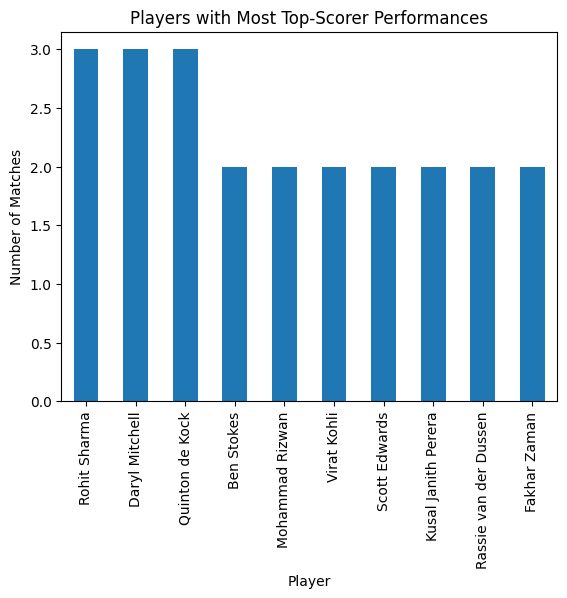

In [ ]:
top_scorers['Batsman_Name'].value_counts().head(10).plot(kind='bar')

plt.title("Players with Most Top-Scorer Performances")
plt.xlabel("Player")
plt.ylabel("Number of Matches")

plt.show()

### 2. BEST BOWLER ANALYSIS

In [ ]:
top_bowlers = bowling.loc[bowling.groupby('Match_no')['Wickets'].idxmax()]
top_bowlers[['Match_no', 'player_name', 'Wickets']]

,Match_no,player_name,Wickets
1,1,Matt Henry,3
16,2,Bas de Leede,4
29,3,Shakib Al Hasan,3
48,4,Gerald Coetzee,3
54,5,Ravindra Jadeja,3
70,6,Mitchell Santner,5
77,7,Mahedi Hasan,4
87,8,Hasan Ali,4
99,9,Jasprit Bumrah,4
120,10,Kagiso Rabada,3


In [ ]:
top_bowlers['Bowler_Name'].value_counts().head(10)

,count
Bowler_Name,
Bas de Leede,3
Jasprit Bumrah,3
Gerald Coetzee,3
Mohammed Shami,3
Trent Boult,2
Mitchell Santner,2
Logan van Beek,2
Dilshan Madushanka,2
Ravindra Jadeja,2


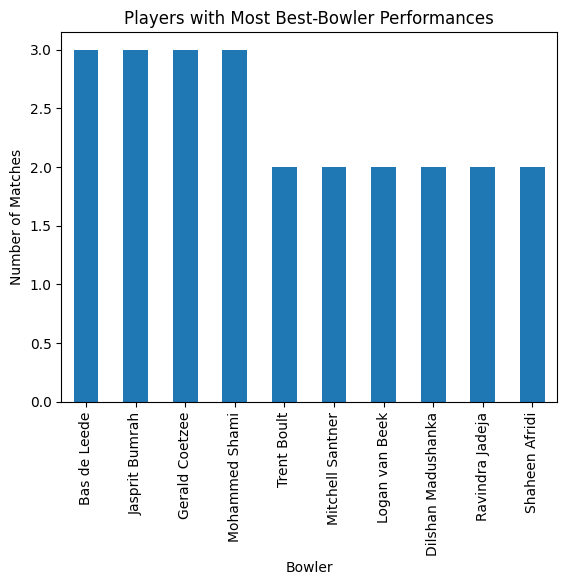

In [ ]:
top_bowlers['Bowler_Name'].value_counts().head(10).plot(kind='bar')

plt.title("Players with Most Best-Bowler Performances")
plt.xlabel("Bowler")
plt.ylabel("Number of Matches")

plt.show()

### 3. STADIUM ANALYSIS

##### Best Stadium for Batting First

In [ ]:
matches['bat_first_win'] = np.where(matches['Winner'] == matches['Team1'], 1, 0)
stadium_batting = matches.groupby('Venue')['bat_first_win'].sum().sort_values(ascending=False)

stadium_batting.head(10)

,bat_first_win
Venue,
Ahmedabad,0
Bengaluru,0
Chennai,0
Delhi,0
Dharamsala,0
Ekana Cricket Stadium Lucknow,0
"Himachal Pradesh Cricket Association Stadium, Dharamsala",0
Hyderabad,0
Kolkata,0


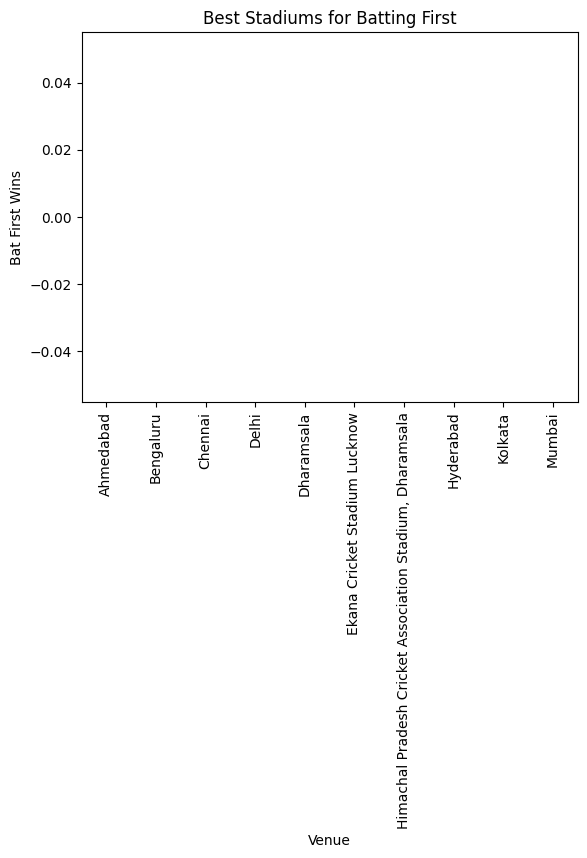

In [ ]:
stadium_batting.head(10).plot(kind='bar')

plt.title("Best Stadiums for Batting First")
plt.xlabel("Venue")
plt.ylabel("Bat First Wins")

plt.show()

##### Best Stadium for Bowling First

In [ ]:
matches['bowl_first_win'] = 1 - matches['bat_first_win']
stadium_bowling = matches.groupby('Venue')['bowl_first_win'].sum().sort_values(ascending=False)

stadium_bowling.head(10)

,bowl_first_win
Venue,
Ahmedabad,5
Bengaluru,5
Chennai,5
Delhi,5
Ekana Cricket Stadium Lucknow,5
Mumbai,5
Kolkata,5
Pune,5
Dharamsala,4


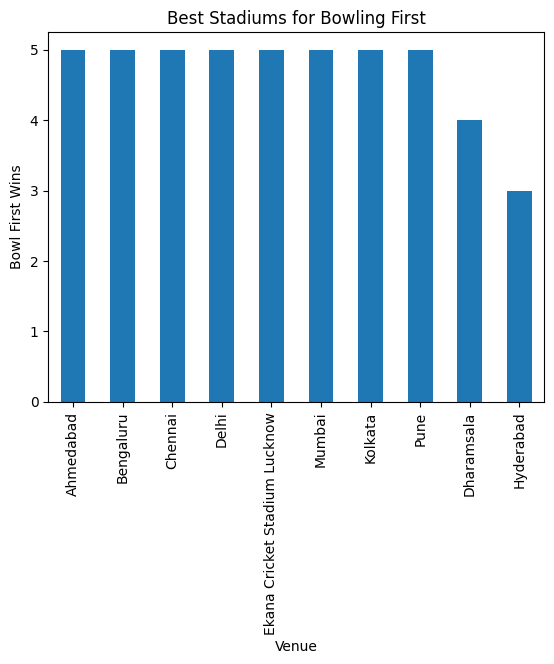

In [ ]:
stadium_bowling.head(10).plot(kind='bar')

plt.title("Best Stadiums for Bowling First")
plt.xlabel("Venue")
plt.ylabel("Bowl First Wins")

plt.show()

### 3. TEAM PERFORMANCE ANALYSIS

##### Most Match Wins

In [ ]:
matches['Winner'].value_counts()

,count
Winner,
Australia,9
India,9
South Africa,7
New Zealand,5
Pakistan,4
Afghanistan,4
Sri Lanka,3
England,3
Bangladesh,2


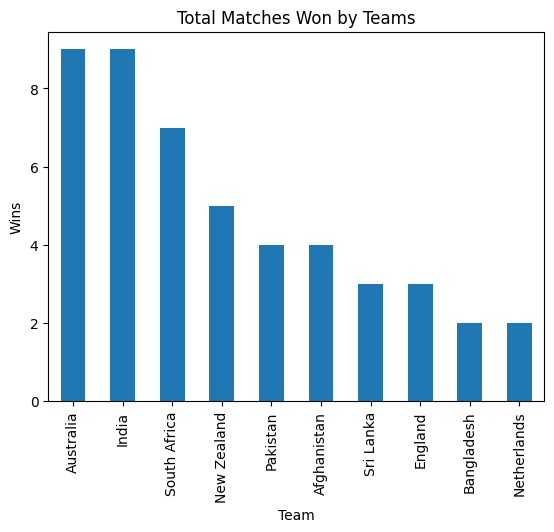

In [ ]:
matches['Winner'].value_counts().plot(kind='bar')

plt.title("Total Matches Won by Teams")
plt.xlabel("Team")
plt.ylabel("Wins")

plt.show()

##### Team-wise Bat First Wins

In [ ]:
bat_first_team = matches[matches['bat_first_win'] == 1]['Winner'].value_counts()

bat_first_team

,count
Winner,


##### Team-wise Bowl First Wins

In [ ]:
bowl_first_team = matches[matches['bowl_first_win'] == 1]['Winner'].value_counts()

bowl_first_team

,count
Winner,
Australia,9
India,9
South Africa,7
New Zealand,5
Pakistan,4
Afghanistan,4
Sri Lanka,3
England,3
Bangladesh,2


### 4. PLAYER ROLE ANALYSIS

##### Count of Player Roles

In [ ]:
players['playingRole'].value_counts()

,count
playingRole,
Bowler,46
Top order Batter,28
Allrounder,22
Wicketkeeper Batter,15
,10
Middle order Batter,9
Batting Allrounder,8
Opening Batter,7
Bowling Allrounder,4


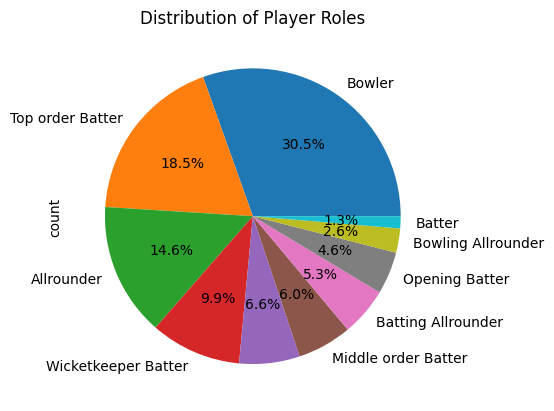

In [ ]:
players['playingRole'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Distribution of Player Roles")

plt.show()